распределение классов визуализация

/tmp/ipykernel_40458/1576466223.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='Количество', y='Класс', palette='magma')


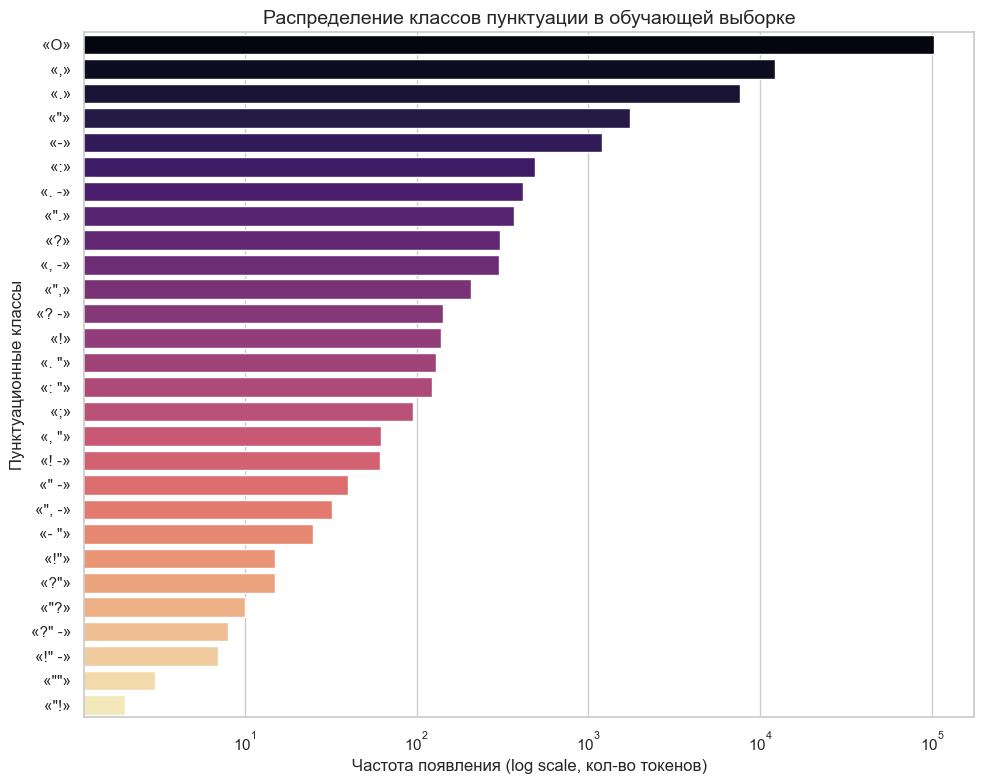

In [ ]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

with open('results/01_baseline_ce.json') as f:
    raw_data = json.load(f)['General_Test']

exclude = ['macro avg', 'weighted avg', 'accuracy']
data = []
for punct, stats in raw_data.items():
    if punct not in exclude and isinstance(stats, dict):
        data.append({'Класс': f"«{punct}»", 'Количество': stats['support']})

df = pd.DataFrame(data).sort_values('Количество', ascending=False)

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=df, x='Количество', y='Класс', palette='magma')

ax.set_xscale("log")
ax.set_title("Распределение классов пунктуации в обучающей выборке", fontsize=14)
ax.set_xlabel("Частота появления (log scale, кол-во токенов)", fontsize=12)
ax.set_ylabel("Пунктуационные классы", fontsize=12)

plt.tight_layout()
plt.savefig("class_distribution_final.png", dpi=300)
plt.show()

crf heatmap

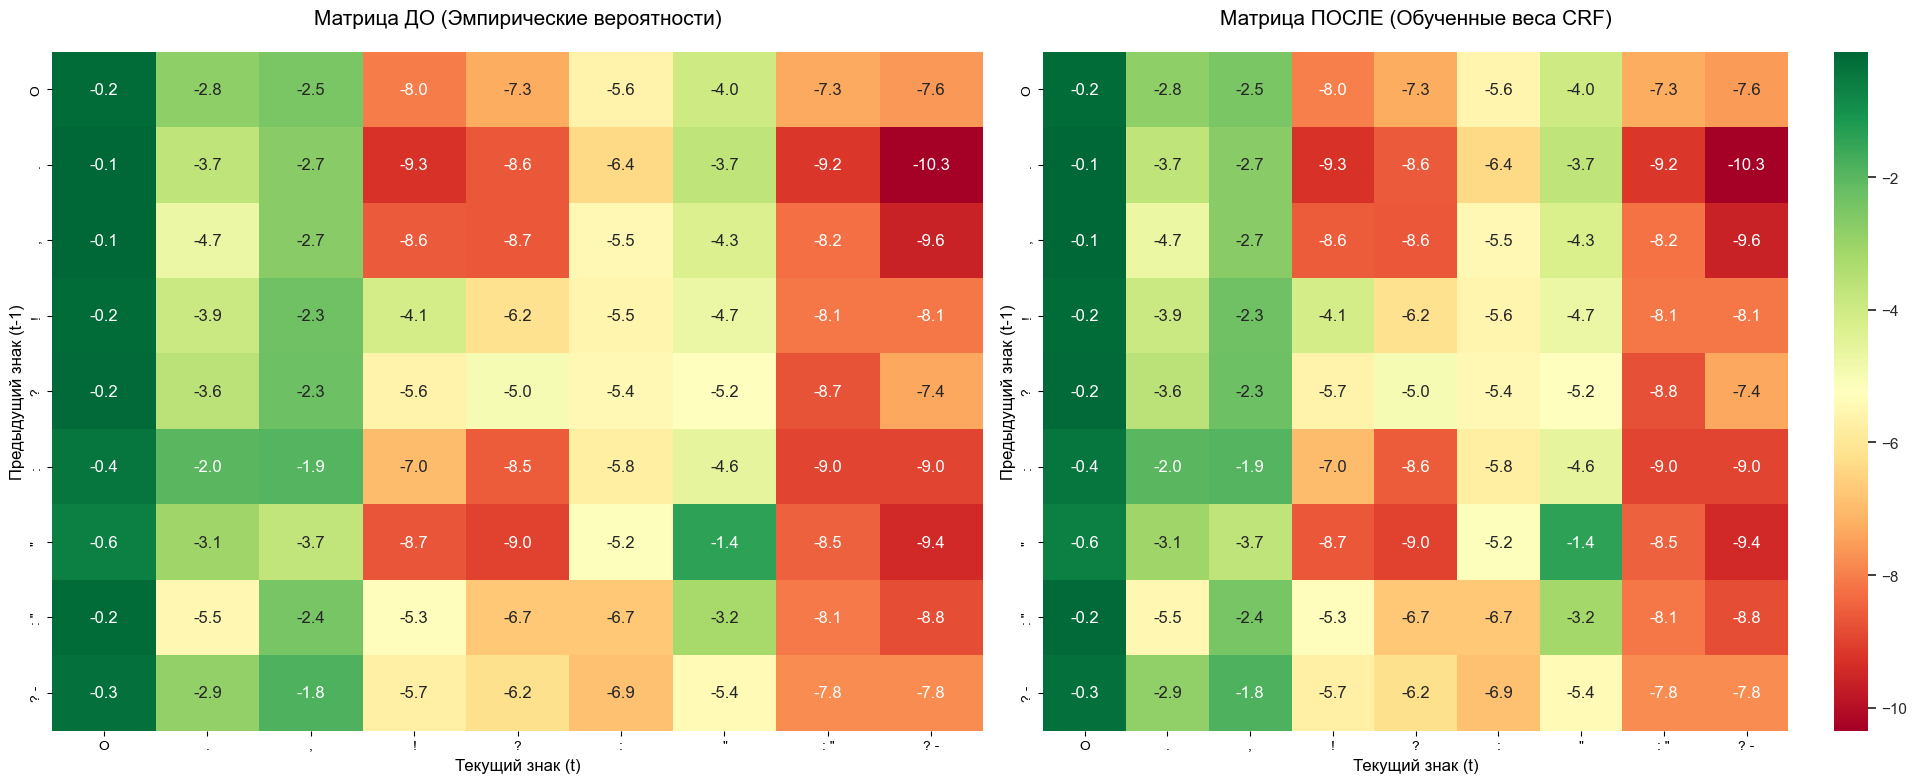

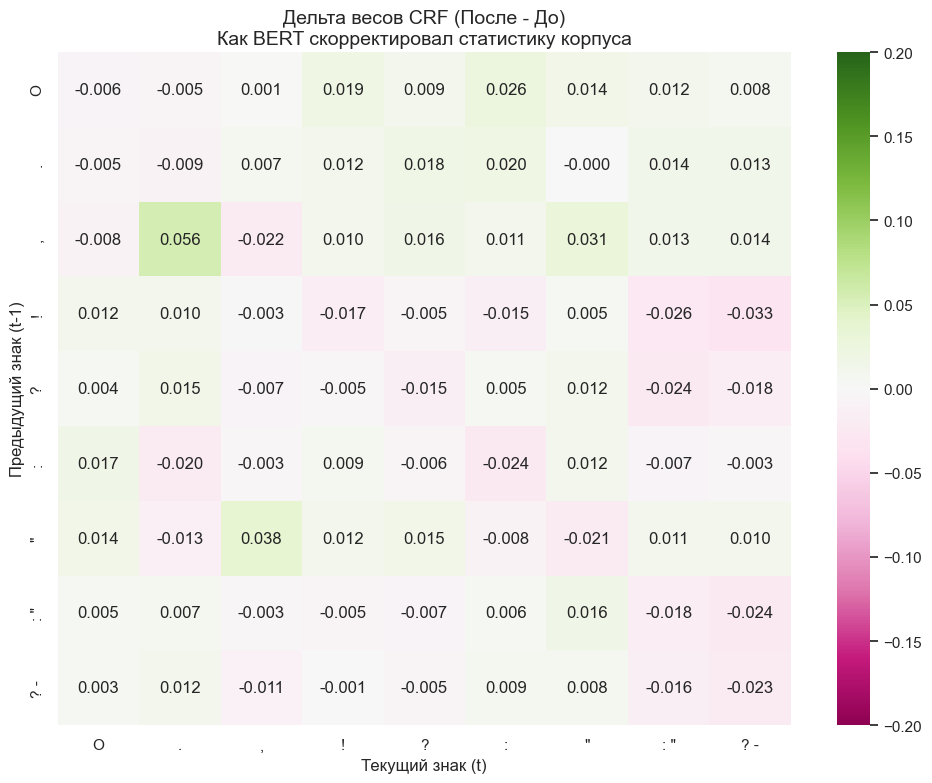

In [ ]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pipeline.training import compute_empirical_transitions
from pipeline.env import DATA_DIR

labels =["O", ".", ",", "!", "?", ":", ";", "-", '"', 
          ', "', ': "', '. "', '"?', '"!', '",', '".', '?"', '!"', 
          '" -', '- "', '", -', '!" -', '?" -', '. -', '""', 
          "! -", "? -", ", -"]

num_labels = len(labels)

train_files =[f"{DATA_DIR}/train_all.json"]
raw_before = compute_empirical_transitions(train_files, num_labels)

if isinstance(raw_before, tuple):
    raw_before = raw_before[0]

if torch.is_tensor(raw_before):
    matrix_before = raw_before.cpu().numpy()
else:
    matrix_before = np.array(raw_before)

model_path = "models/02_baseline_crf_transitions/pytorch_model.bin"
checkpoint = torch.load(model_path, map_location='cpu', weights_only=True)
matrix_after = checkpoint['crf.transitions'].cpu().numpy()

interesting_indices =[0, 1, 2, 3, 4, 5, 8, 10, 26]
sub_labels = [labels[i] for i in interesting_indices]

idx = np.array(interesting_indices)
m_before_sub = matrix_before[np.ix_(idx, idx)]
m_after_sub = matrix_after[np.ix_(idx, idx)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
sns.set_theme(style="white")

vmin = min(m_before_sub.min(), m_after_sub.min())
vmax = max(m_before_sub.max(), m_after_sub.max())

heatmap_kwargs = {
    'annot': True,
    'fmt': ".1f",
    'cmap': "RdYlGn",
    'xticklabels': sub_labels,
    'yticklabels': sub_labels,
    'vmin': vmin,
    'vmax': vmax
}

sns.heatmap(m_before_sub, ax=ax1, cbar=False, **heatmap_kwargs)
ax1.set_title("Матрица ДО (Эмпирические вероятности)", fontsize=15, pad=20)

sns.heatmap(m_after_sub, ax=ax2, **heatmap_kwargs)
ax2.set_title("Матрица ПОСЛЕ (Обученные веса CRF)", fontsize=15, pad=20)

for ax in [ax1, ax2]:
    ax.set_xlabel("Текущий знак (t)", fontsize=12)
    ax.set_ylabel("Предыдущий знак (t-1)", fontsize=12)

plt.tight_layout()
plt.savefig("crf_before_after_comparison.png", dpi=300)
plt.show()

delta_matrix = m_after_sub - m_before_sub

plt.figure(figsize=(10, 8))
sns.set_theme(style="white")
sns.heatmap(delta_matrix, annot=True, fmt=".3f", cmap="PiYG", center=0,
            xticklabels=sub_labels, yticklabels=sub_labels, 
            vmin=-0.2, vmax=0.2)

plt.title("Дельта весов CRF (После - До)\nКак BERT скорректировал статистику корпуса", fontsize=14)
plt.xlabel("Текущий знак (t)")
plt.ylabel("Предыдущий знак (t-1)")
plt.tight_layout()
plt.savefig("crf_delta.png", dpi=300)
plt.show()

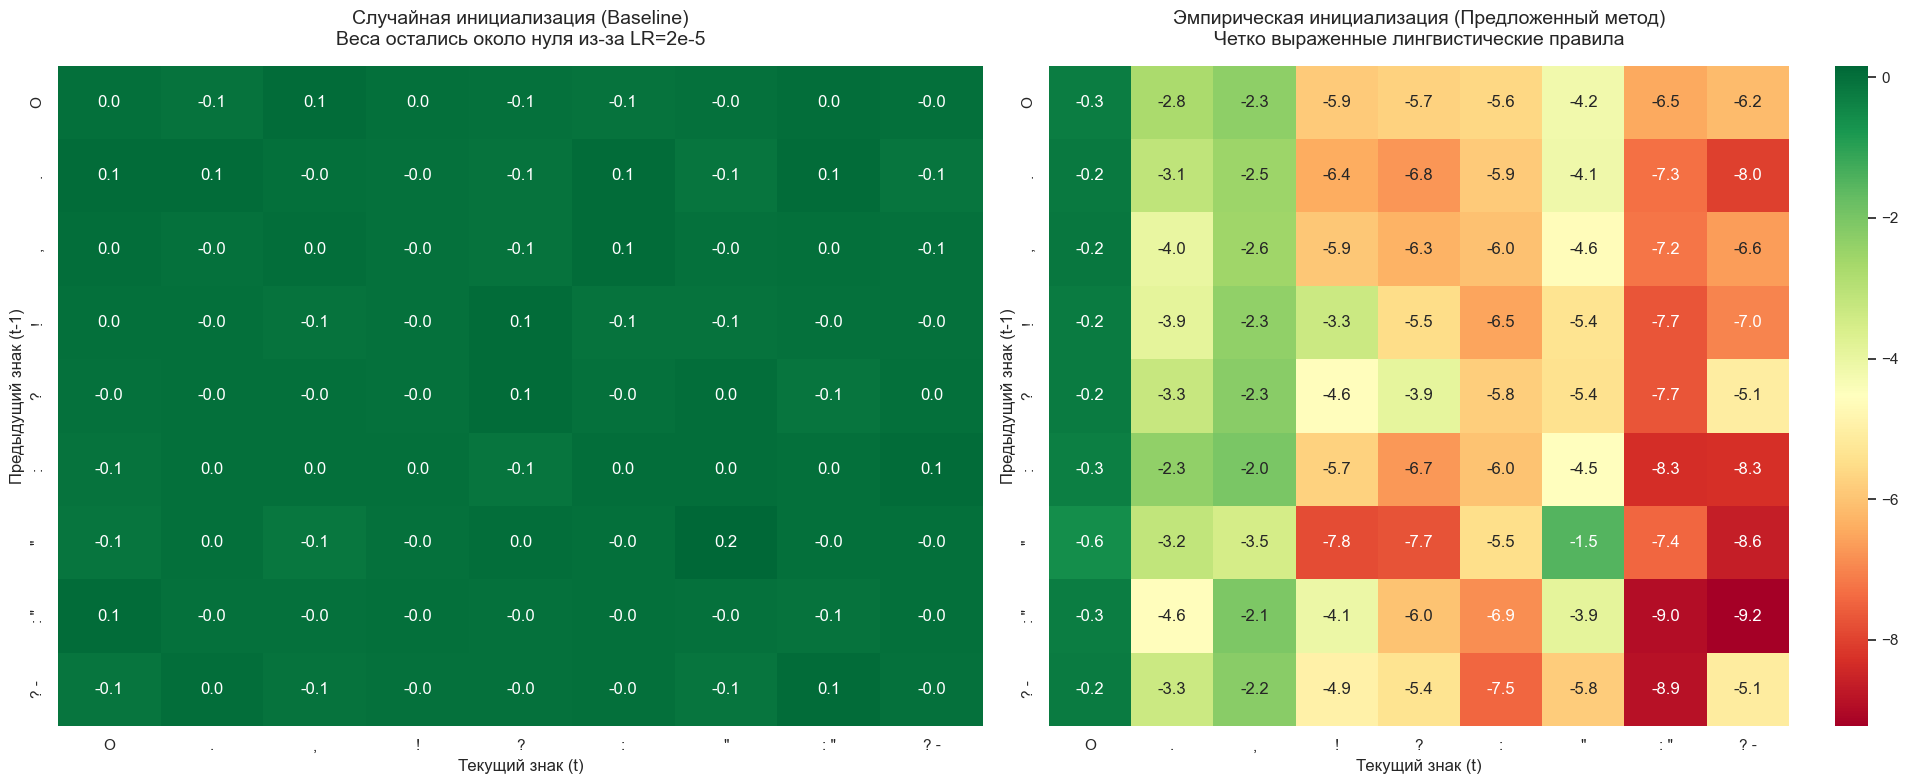

In [3]:
model_01_path = "models/01_baseline_crf/pytorch_model.bin"
checkpoint_01 = torch.load(model_01_path, map_location='cpu', weights_only=True)
matrix_01_dumb = checkpoint_01['crf.transitions'].cpu().numpy()

model_02_path = "models/03_crf_transitions_mined/pytorch_model.bin"
checkpoint_02 = torch.load(model_02_path, map_location='cpu', weights_only=True)
matrix_02_smart = checkpoint_02['crf.transitions'].cpu().numpy()

m_01_sub = matrix_01_dumb[np.ix_(idx, idx)]
m_02_sub = matrix_02_smart[np.ix_(idx, idx)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

vmin = min(m_01_sub.min(), m_02_sub.min())
vmax = max(m_01_sub.max(), m_02_sub.max())

sns.heatmap(m_01_sub, ax=ax1, annot=True, fmt=".1f", cmap="RdYlGn", 
            xticklabels=sub_labels, yticklabels=sub_labels, vmin=vmin, vmax=vmax, cbar=False)
ax1.set_title("Случайная инициализация (Baseline)\nВеса остались около нуля из-за LR=2e-5", fontsize=14, pad=15)

sns.heatmap(m_02_sub, ax=ax2, annot=True, fmt=".1f", cmap="RdYlGn", 
            xticklabels=sub_labels, yticklabels=sub_labels, vmin=vmin, vmax=vmax)
ax2.set_title("Эмпирическая инициализация (Предложенный метод)\nЧетко выраженные лингвистические правила", fontsize=14, pad=15)

for ax in[ax1, ax2]:
    ax.set_xlabel("Текущий знак (t)", fontsize=12)
    ax.set_ylabel("Предыдущий знак (t-1)", fontsize=12)

plt.tight_layout()
plt.savefig("crf_smart_vs_dumb.png", dpi=300)
plt.show()

Линейный график роста метрик

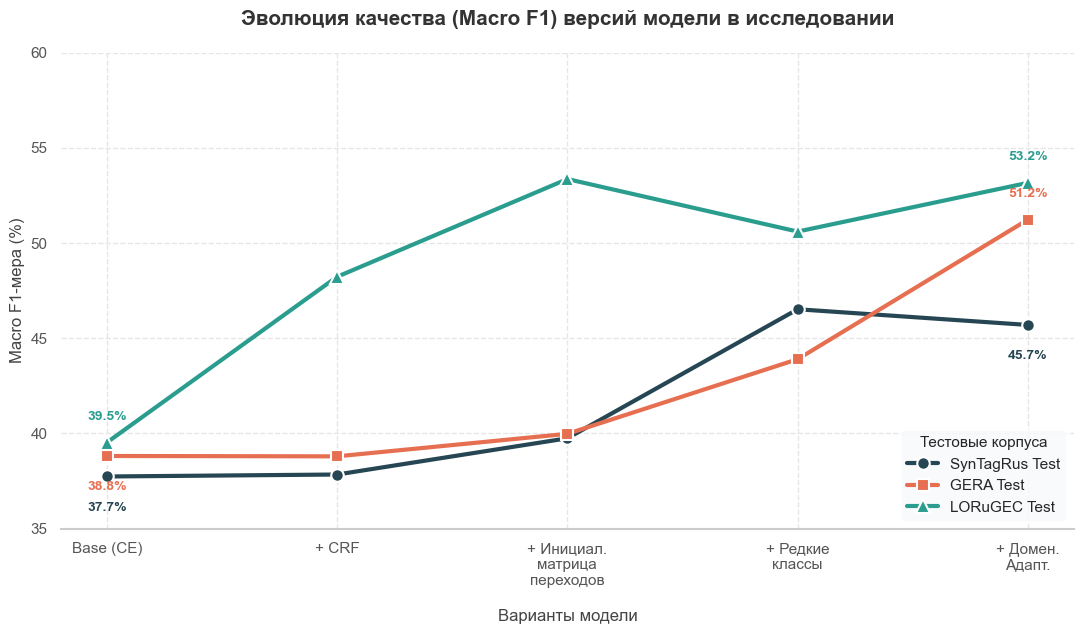

In [8]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

with open('results/models_db.json', 'r', encoding='utf-8') as f:
    db = json.load(f)

stages =[
    "01_baseline_ce",
    "01_baseline_crf",
    "02_baseline_crf_transitions",
    "03_crf_transitions_mined_v2",
    "04b_finetune_replay_v3"
]

x_labels =[
    "Base (CE)", 
    "+ CRF", 
    "+ Инициал.\nматрица\nпереходов", 
    "+ Редкие\nклассы", 
    "+ Домен.\nАдапт."
]

f1_general, f1_gera, f1_lorugec = [], [],[]

for model in stages:
    f1_general.append(db[model]['General_Test']['macro avg']['f1-score'] * 100)
    f1_gera.append(db[model]['GERA_Test']['macro avg']['f1-score'] * 100)
    f1_lorugec.append(db[model]['LORuGEC_Test']['macro avg']['f1-score'] * 100)

sns.set_theme(style="whitegrid", rc={"grid.color": ".9", "grid.linestyle": "--"})

COLORS = {
    'General': '#264653',
    'GERA': '#E76F51',
    'LORuGEC': '#2A9D8F'
}

plt.figure(figsize=(11, 6.5))

plt.plot(x_labels, f1_general, marker='o', linewidth=3, markersize=9, 
         color=COLORS['General'], markeredgecolor='white', markeredgewidth=1.5, 
         zorder=3, label='SynTagRus Test')

plt.plot(x_labels, f1_gera, marker='s', linewidth=3, markersize=9, 
         color=COLORS['GERA'], markeredgecolor='white', markeredgewidth=1.5, 
         zorder=3, label='GERA Test')

plt.plot(x_labels, f1_lorugec, marker='^', linewidth=3, markersize=10, 
         color=COLORS['LORuGEC'], markeredgecolor='white', markeredgewidth=1.5, 
         zorder=3, label='LORuGEC Test')

plt.title('Эволюция качества (Macro F1) версий модели в исследовании', 
          fontsize=15, fontweight='600', pad=20, color='#333333')
plt.ylabel('Macro F1-мера (%)', fontsize=12, fontweight='500', color='#444444')
plt.xlabel('Варианты модели', fontsize=12, fontweight='500', color='#444444', labelpad=15)

plt.ylim(35, 60)
plt.yticks(fontsize=11, color='#555555')
plt.xticks(fontsize=11, color='#555555')

plt.legend(title="Тестовые корпуса", title_fontsize='11', fontsize=11, 
           loc='lower right', frameon=True, edgecolor='white', facecolor='#F8F9FA')

plt.text(0, f1_general[0] - 1.8, f"{f1_general[0]:.1f}%", ha='center', fontsize=10, fontweight='bold', color=COLORS['General'])
plt.text(4, f1_general[-1] - 1.8, f"{f1_general[-1]:.1f}%", ha='center', fontsize=10, fontweight='bold', color=COLORS['General'])

plt.text(0, f1_gera[0] - 1.8, f"{f1_gera[0]:.1f}%", ha='center', fontsize=10, fontweight='bold', color=COLORS['GERA'])
plt.text(4, f1_gera[-1] + 1.2, f"{f1_gera[-1]:.1f}%", ha='center', fontsize=10, fontweight='bold', color=COLORS['GERA'])

plt.text(0, f1_lorugec[0] + 1.2, f"{f1_lorugec[0]:.1f}%", ha='center', fontsize=10, fontweight='bold', color=COLORS['LORuGEC'])
plt.text(4, f1_lorugec[-1] + 1.2, f"{f1_lorugec[-1]:.1f}%", ha='center', fontsize=10, fontweight='bold', color=COLORS['LORuGEC'])

sns.despine(left=True, bottom=False)
plt.gca().spines['bottom'].set_color('#CCCCCC')
plt.gca().spines['bottom'].set_linewidth(1.5)

plt.tight_layout()
plt.savefig('pipeline_evolution_premium.pdf', dpi=300)
plt.savefig('pipeline_evolution_premium.png', dpi=300)

plt.show()